# 04 — Siamese CNN per FCGR di eccDNA

## Obiettivo

Questo notebook implementa il primo modello Siamese della pipeline.

Ogni ramo della rete riceve una FCGR normalizzata e utilizza lo stesso
CNN encoder per trasformarla in un embedding.

La pipeline è:

DNA / eccDNA
→ FCGR
→ CNN encoder condiviso
→ embedding
→ distanza euclidea
→ Contrastive Loss

Le coppie positive appartengono alla stessa classe patologica, mentre le
coppie negative appartengono a classi differenti.

In questa prima baseline vengono utilizzati:

- FCGR con `k = 6` (`64 × 64`);
- embedding dimension = `128`;
- distanza euclidea;
- Contrastive Loss;
- target `1` per coppie positive;
- target `0` per coppie negative.

La classificazione multiclass tramite prototipi degli embedding verrà
affrontata successivamente.

In [1]:
from pathlib import Path

import json
import random
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)


print(
    "PyTorch:",
    torch.__version__
)

print(
    "CUDA disponibile:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

PyTorch: 2.12.0+cu126
CUDA disponibile: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
CURRENT_DIR = (
    Path.cwd()
    .resolve()
)


if CURRENT_DIR.name == "notebooks":

    PROJECT_ROOT = (
        CURRENT_DIR.parent
    )

else:

    PROJECT_ROOT = (
        CURRENT_DIR
    )


PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


ARTIFACTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "siamese_margin_075"
)

ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PAIR_CONFIG_PATH = (
    PROCESSED_DIR
    / "siamese_pair_config.json"
)


MANIFEST_PATH = (
    PROCESSED_DIR
    / "siamese_primary_manifest.tsv"
)


VAL_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_val_pair_pool.tsv"
)


TEST_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_test_pair_pool.tsv"
)


with open(
    PAIR_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:

    PAIR_CONFIG = json.load(f)


DEFAULT_K = int(
    PAIR_CONFIG["k"]
)


# ============================================================
# BASELINE D
# ============================================================

ORIGINAL_BATCH_SIZE = int(
    PAIR_CONFIG["batch_size"]
)

BATCH_SIZE = 128


TRAIN_PAIRS_PER_EPOCH = int(
    PAIR_CONFIG[
        "train_pairs_per_epoch"
    ]
)


VAL_PAIRS = int(
    PAIR_CONFIG["val_pairs"]
)


TEST_PAIRS = int(
    PAIR_CONFIG["test_pairs"]
)


POSITIVE_PAIR_PROBABILITY = float(
    PAIR_CONFIG[
        "positive_probability"
    ]
)


RANDOM_STATE = int(
    PAIR_CONFIG["random_state"]
)


FCGR_MEMMAP_PATH = (
    PROCESSED_DIR
    / "fcgr_cache"
    / f"fcgr_k{DEFAULT_K}.npy"
)


FCGR_INDEX_PATH = (
    PROCESSED_DIR
    / "fcgr_cache"
    / f"fcgr_k{DEFAULT_K}_index.tsv"
)


print(
    "Project root:",
    PROJECT_ROOT
)

print(
    "k:",
    DEFAULT_K
)

print(
    "Batch Baseline A:",
    ORIGINAL_BATCH_SIZE
)

print(
    "Batch Baseline B:",
    BATCH_SIZE
)

print(
    "Train pairs / epoch:",
    TRAIN_PAIRS_PER_EPOCH
)

Project root: D:\Daria\Desktop\eccdna_fcgr_siamese
k: 6
Batch Baseline A: 64
Batch Baseline B: 128
Train pairs / epoch: 50000


In [3]:
def set_seed(
    seed
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


set_seed(
    RANDOM_STATE
)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Device:",
    DEVICE
)

if DEVICE.type == "cuda":

    torch.backends.cudnn.benchmark = True

    torch.set_float32_matmul_precision(
        "high"
    )


print(
    "cuDNN benchmark:",
    torch.backends.cudnn.benchmark
)

Device: cuda
cuDNN benchmark: True


In [5]:
metadata = pd.read_csv(
    MANIFEST_PATH,
    sep="\t",
    dtype={
        "id": str
    }
)


val_pair_pool = pd.read_csv(
    VAL_POOL_PATH,
    sep="\t",
    dtype={
        "id": str
    }
)


test_pair_pool = pd.read_csv(
    TEST_POOL_PATH,
    sep="\t",
    dtype={
        "id": str
    }
)


train_metadata = (
    metadata[
        metadata[
            "split_cluster"
        ] == "train"
    ]
    .copy()
)


for dataframe in [
    train_metadata,
    val_pair_pool,
    test_pair_pool
]:

    dataframe[
        "class_id"
    ] = (
        dataframe[
            "class_id"
        ]
        .astype(int)
    )


print(
    "Train samples:",
    f"{len(train_metadata):,}"
)

print(
    "Validation pool:",
    f"{len(val_pair_pool):,}"
)

print(
    "Test pool:",
    f"{len(test_pair_pool):,}"
)

print(
    "Classi:",
    train_metadata[
        "class_id"
    ].nunique()
)

Train samples: 126,265
Validation pool: 12,937
Test pool: 11,070
Classi: 18


In [6]:
fcgr_memmap = np.load(
    FCGR_MEMMAP_PATH,
    mmap_mode="r"
)


fcgr_index = pd.read_csv(
    FCGR_INDEX_PATH,
    sep="\t",
    dtype={
        "id": str
    }
)


id_to_fcgr_row = dict(
    zip(
        fcgr_index[
            "id"
        ],

        fcgr_index[
            "fcgr_row"
        ]
    )
)


print(
    "FCGR shape:",
    fcgr_memmap.shape
)

print(
    "FCGR dtype:",
    fcgr_memmap.dtype
)

print(
    "Indice:",
    len(
        id_to_fcgr_row
    )
)


assert (
    fcgr_memmap.dtype
    == np.float32
)


assert (
    len(
        id_to_fcgr_row
    )
    ==
    fcgr_memmap.shape[0]
)

FCGR shape: (150272, 64, 64)
FCGR dtype: float32
Indice: 150272


In [7]:
class SiamesePairDataset(
    Dataset
):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row,
        pairs_per_epoch,
        positive_probability=0.5,
        seed=42,
        deterministic=False
    ):

        self.metadata = (
            metadata
            .copy()
            .reset_index(drop=True)
        )


        self.fcgr_memmap = (
            fcgr_memmap
        )


        self.id_to_row = (
            id_to_row
        )


        self.pairs_per_epoch = int(
            pairs_per_epoch
        )


        self.positive_probability = float(
            positive_probability
        )


        self.seed = int(
            seed
        )


        self.deterministic = (
            deterministic
        )


        self.rng = (
            np.random.default_rng(
                self.seed
            )
        )


        self.class_to_ids = {

            int(class_id):
            group["id"]
            .astype(str)
            .tolist()

            for class_id, group
            in self.metadata.groupby(
                "class_id"
            )
        }


        self.classes = np.array(
            sorted(
                self.class_to_ids.keys()
            ),
            dtype=np.int64
        )


        for class_id in self.classes:

            if (
                len(
                    self.class_to_ids[
                        int(class_id)
                    ]
                )
                < 2
            ):

                raise ValueError(
                    f"Classe {class_id} "
                    "con meno di 2 sample."
                )


    def __len__(
        self
    ):

        return (
            self.pairs_per_epoch
        )


    def _get_rng(
        self,
        index
    ):

        if self.deterministic:

            return (
                np.random.default_rng(
                    self.seed
                    + int(index)
                )
            )

        return (
            self.rng
        )


    def _sample_pair(
        self,
        rng
    ):

        # ----------------------------------
        # Classe anchor
        # ----------------------------------

        class1 = int(
            rng.choice(
                self.classes
            )
        )


        ids_class1 = (
            self.class_to_ids[
                class1
            ]
        )


        id1 = str(
            rng.choice(
                ids_class1
            )
        )


        # ----------------------------------
        # Positive pair
        # ----------------------------------

        if (
            rng.random()
            <
            self.positive_probability
        ):

            class2 = (
                class1
            )


            id2 = (
                id1
            )


            while (
                id2
                ==
                id1
            ):

                id2 = str(
                    rng.choice(
                        ids_class1
                    )
                )


            target = (
                1.0
            )


        # ----------------------------------
        # Negative pair
        # ----------------------------------

        else:

            possible_classes = (
                self.classes[
                    self.classes
                    != class1
                ]
            )


            class2 = int(
                rng.choice(
                    possible_classes
                )
            )


            id2 = str(
                rng.choice(
                    self.class_to_ids[
                        class2
                    ]
                )
            )


            target = (
                0.0
            )


        return (
            id1,
            id2,
            class1,
            class2,
            target
        )


    def _load_fcgr(
        self,
        sample_id
    ):

        row = (
            self.id_to_row[
                str(sample_id)
            ]
        )


        fcgr = np.array(
            self.fcgr_memmap[
                row
            ],
            dtype=np.float32,
            copy=True
        )


        tensor = (
            torch.from_numpy(
                fcgr
            )
            .unsqueeze(0)
        )


        return tensor


    def __getitem__(
        self,
        index
    ):

        rng = (
            self._get_rng(
                index
            )
        )


        (
            id1,
            id2,
            class1,
            class2,
            target
        ) = (
            self._sample_pair(
                rng
            )
        )


        x1 = (
            self._load_fcgr(
                id1
            )
        )


        x2 = (
            self._load_fcgr(
                id2
            )
        )


        return {

            "x1":
                x1,

            "x2":
                x2,

            "target":
                torch.tensor(
                    target,
                    dtype=torch.float32
                ),

            "id1":
                id1,

            "id2":
                id2,

            "class1":
                class1,

            "class2":
                class2
        }

In [8]:
train_dataset = SiamesePairDataset(

    metadata=
        train_metadata,

    fcgr_memmap=
        fcgr_memmap,

    id_to_row=
        id_to_fcgr_row,

    pairs_per_epoch=
        TRAIN_PAIRS_PER_EPOCH,

    positive_probability=
        POSITIVE_PAIR_PROBABILITY,

    seed=
        RANDOM_STATE,

    deterministic=False
)


val_dataset = SiamesePairDataset(

    metadata=
        val_pair_pool,

    fcgr_memmap=
        fcgr_memmap,

    id_to_row=
        id_to_fcgr_row,

    pairs_per_epoch=
        VAL_PAIRS,

    positive_probability=
        POSITIVE_PAIR_PROBABILITY,

    seed=
        RANDOM_STATE + 10_000,

    deterministic=True
)


test_dataset = SiamesePairDataset(

    metadata=
        test_pair_pool,

    fcgr_memmap=
        fcgr_memmap,

    id_to_row=
        id_to_fcgr_row,

    pairs_per_epoch=
        TEST_PAIRS,

    positive_probability=
        POSITIVE_PAIR_PROBABILITY,

    seed=
        RANDOM_STATE + 20_000,

    deterministic=True
)


NUM_WORKERS = 0


train_loader = DataLoader(

    train_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        torch.cuda.is_available()
)


val_loader = DataLoader(

    val_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        torch.cuda.is_available()
)


test_loader = DataLoader(

    test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        torch.cuda.is_available()
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 391
Validation batches: 79
Test batches: 79


In [9]:
batch = next(
    iter(
        train_loader
    )
)


print(
    "x1:",
    batch["x1"].shape,
    batch["x1"].dtype
)

print(
    "x2:",
    batch["x2"].shape,
    batch["x2"].dtype
)

print(
    "target:",
    batch["target"].shape,
    batch["target"].dtype
)


print()

print(
    "Positive:",
    (
        batch[
            "target"
        ] == 1
    ).sum().item()
)

print(
    "Negative:",
    (
        batch[
            "target"
        ] == 0
    ).sum().item()
)


assert (
    batch["x1"].shape[1:]
    ==
    (
        1,
        64,
        64
    )
)


assert (
    batch["x1"].dtype
    ==
    torch.float32
)

x1: torch.Size([128, 1, 64, 64]) torch.float32
x2: torch.Size([128, 1, 64, 64]) torch.float32
target: torch.Size([128]) torch.float32

Positive: 68
Negative: 60


# CNN Encoder

La rete Siamese utilizza un unico CNN encoder condiviso tra i due rami.

Questo significa che entrambe le FCGR vengono processate dagli stessi
parametri θ:

`z1 = Encoder(x1)`

`z2 = Encoder(x2)`

L'encoder produce un embedding di 128 dimensioni.

Gli embedding vengono normalizzati tramite norma L2. In questo modo
la loro scala rimane controllata e la distanza euclidea dipende
principalmente dalla posizione relativa dei sample nello spazio degli
embedding.

In [10]:
class FCGRCNNEncoder(
    nn.Module
):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()


        self.features = nn.Sequential(

            # ==============================
            # 64 x 64
            # ==============================

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=32
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                32,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.MaxPool2d(
                kernel_size=2
            ),


            # ==============================
            # 32 x 32
            # ==============================

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=64
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.MaxPool2d(
                kernel_size=2
            ),


            # ==============================
            # 16 x 16
            # ==============================

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=128
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.MaxPool2d(
                kernel_size=2
            ),


            # ==============================
            # 8 x 8
            # ==============================

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.GroupNorm(
                num_groups=8,
                num_channels=128
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.AdaptiveAvgPool2d(
                (
                    4,
                    4
                )
            )
        )


        self.projection = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 4 * 4,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                256,
                embedding_dim
            )
        )


    def forward(
        self,
        x
    ):

        x = self.features(
            x
        )


        z = self.projection(
            x
        )


        z = F.normalize(
            z,
            p=2,
            dim=1
        )


        return z

In [11]:
class SiameseNetwork(
    nn.Module
):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()


        self.encoder = FCGRCNNEncoder(
            embedding_dim=
                embedding_dim
        )


    def forward(
        self,
        x1,
        x2
    ):

        # Un'unica chiamata all'encoder
        # invece di due chiamate separate.

        x = torch.cat(
            [
                x1,
                x2
            ],
            dim=0
        )


        z = self.encoder(
            x
        )


        z1, z2 = torch.chunk(
            z,
            chunks=2,
            dim=0
        )


        return (
            z1,
            z2
        )

In [12]:
class ContrastiveLoss(
    nn.Module
):

    def __init__(
        self,
        margin=1.0
    ):

        super().__init__()

        self.margin = float(
            margin
        )


    def forward(
        self,
        z1,
        z2,
        target
    ):

        distance = (
            F.pairwise_distance(
                z1,
                z2,
                p=2
            )
        )


        positive_loss = (
            target
            *
            distance.pow(2)
        )


        negative_loss = (

            (1.0 - target)

            *

            F.relu(
                self.margin
                -
                distance
            ).pow(2)
        )


        loss = (
            positive_loss
            +
            negative_loss
        )


        return (
            loss.mean(),
            distance
        )

In [13]:
EMBEDDING_DIM = 128

MARGIN = 0.75


model = SiameseNetwork(
    embedding_dim=
        EMBEDDING_DIM
)


model = model.to(
    DEVICE
)


criterion = ContrastiveLoss(
    margin=
        MARGIN
)


n_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
)


n_trainable_parameters = sum(
    parameter.numel()
    for parameter
    in model.parameters()
    if parameter.requires_grad
)


print(
    model
)


print()

print(
    "Parametri totali:",
    f"{n_parameters:,}"
)

print(
    "Parametri trainabili:",
    f"{n_trainable_parameters:,}"
)

SiameseNetwork(
  (encoder): FCGRCNNEncoder(
    (features): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU(inplace=True)
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): GroupNorm(8, 128, eps=1e-05, affine=True, bias=True)
      (12): ReLU(inplace=True)
      (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (14): Conv2d(128, 128, kernel_size=(3, 3)

In [14]:
model.eval()


x1 = (
    batch["x1"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


x2 = (
    batch["x2"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


targets = (
    batch["target"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


with torch.no_grad():

    z1, z2 = model(
        x1,
        x2
    )


    loss, distances = criterion(
        z1,
        z2,
        targets
    )


print(
    "x1:",
    x1.shape
)

print(
    "z1:",
    z1.shape
)

print(
    "z2:",
    z2.shape
)

print(
    "Loss:",
    loss.item()
)

print(
    "Distance min:",
    distances.min().item()
)

print(
    "Distance max:",
    distances.max().item()
)

print(
    "Distance mean:",
    distances.mean().item()
)

x1: torch.Size([128, 1, 64, 64])
z1: torch.Size([128, 128])
z2: torch.Size([128, 128])
Loss: 0.2580723166465759
Distance min: 0.0007103528478182852
Distance max: 0.06534744799137115
Distance mean: 0.007779830601066351


In [15]:
embedding_norms = torch.linalg.vector_norm(
    z1,
    dim=1
)


print(
    "Norma minima:",
    embedding_norms.min().item()
)

print(
    "Norma massima:",
    embedding_norms.max().item()
)

print(
    "Norma media:",
    embedding_norms.mean().item()
)

Norma minima: 0.9999999403953552
Norma massima: 1.0
Norma media: 1.0


In [16]:
# ============================================================
# TRAIN / EVAL CONSISTENCY CHECK
# ============================================================

diagnostic_batch = next(
    iter(
        val_loader
    )
)


diag_x1 = (
    diagnostic_batch["x1"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


diag_x2 = (
    diagnostic_batch["x2"]
    .to(
        DEVICE,
        non_blocking=True
    )
)


diag_targets = (
    diagnostic_batch["target"]
    .cpu()
    .numpy()
)


# ------------------------------------------------------------
# TRAIN MODE
# ------------------------------------------------------------

model.train()


with torch.no_grad():

    train_z1, train_z2 = model(
        diag_x1,
        diag_x2
    )


    train_distances = (
        F.pairwise_distance(
            train_z1,
            train_z2
        )
        .cpu()
        .numpy()
    )


# ------------------------------------------------------------
# EVAL MODE
# ------------------------------------------------------------

model.eval()


with torch.no_grad():

    eval_z1, eval_z2 = model(
        diag_x1,
        diag_x2
    )


    eval_distances = (
        F.pairwise_distance(
            eval_z1,
            eval_z2
        )
        .cpu()
        .numpy()
    )


print(
    "TRAIN mode mean distance:",
    train_distances.mean()
)

print(
    "EVAL mode mean distance:",
    eval_distances.mean()
)


print(
    "Differenza media:",
    np.abs(
        train_distances
        -
        eval_distances
    ).mean()
)


print()

print(
    "TRAIN d+:",
    train_distances[
        diag_targets == 1
    ].mean()
)

print(
    "TRAIN d-:",
    train_distances[
        diag_targets == 0
    ].mean()
)


print(
    "EVAL d+:",
    eval_distances[
        diag_targets == 1
    ].mean()
)

print(
    "EVAL d-:",
    eval_distances[
        diag_targets == 0
    ].mean()
)

TRAIN mode mean distance: 0.0074086725
EVAL mode mean distance: 0.0074086725
Differenza media: 0.0

TRAIN d+: 0.008970936
TRAIN d-: 0.00589448
EVAL d+: 0.008970936
EVAL d-: 0.00589448


# Training

Il modello viene ottimizzato mediante AdamW.

Il training utilizza coppie generate dinamicamente ad ogni epoca,
mentre validation e test utilizzano coppie deterministiche.

Il checkpoint viene selezionato sulla `validation contrastive loss`.

Il test set non viene utilizzato durante il training né per la scelta
dell'epoca migliore.

In [17]:
EPOCHS = 50

LEARNING_RATE = 5e-4

WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 7

MIN_AUC_DELTA = 1e-4


CHECKPOINT_PATH = (
    ARTIFACTS_DIR
    / "best_siamese_margin_075.pt"
)


HISTORY_PATH = (
    ARTIFACTS_DIR
    / "training_history_C.csv"
)


print(
    "Epoch:",
    EPOCHS
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Patience:",
    EARLY_STOPPING_PATIENCE
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH
)

Epoch: 50
Learning rate: 0.0005
Batch size: 128
Patience: 7
Checkpoint: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\siamese_margin_075\best_siamese_margin_075.pt


In [18]:
def run_epoch(
    model,
    loader,
    criterion,
    device,
    optimizer=None,
    scaler=None
):

    training = (
        optimizer
        is not None
    )


    if training:

        model.train()

    else:

        model.eval()


    total_loss = 0.0

    total_samples = 0


    all_distances = []

    all_targets = []


    for batch in loader:

        x1 = (
            batch["x1"]
            .to(
                device,
                non_blocking=True
            )
        )


        x2 = (
            batch["x2"]
            .to(
                device,
                non_blocking=True
            )
        )


        targets = (
            batch["target"]
            .to(
                device,
                non_blocking=True
            )
        )


        if training:

            optimizer.zero_grad(
                set_to_none=True
            )


        with torch.set_grad_enabled(
            training
        ):

            with torch.autocast(

                device_type=
                    device.type,

                dtype=
                    torch.float16,

                enabled=
                    (
                        device.type
                        ==
                        "cuda"
                    )
            ):

                z1, z2 = model(
                    x1,
                    x2
                )


                loss, distances = (
                    criterion(
                        z1,
                        z2,
                        targets
                    )
                )


        if training:

            scaler.scale(
                loss
            ).backward()


            scaler.step(
                optimizer
            )


            scaler.update()


        batch_size = (
            targets.shape[0]
        )


        total_loss += (
            loss.item()
            *
            batch_size
        )


        total_samples += (
            batch_size
        )


        all_distances.append(

            distances
            .detach()
            .cpu()
            .numpy()
        )


        all_targets.append(

            targets
            .detach()
            .cpu()
            .numpy()
        )


    all_distances = (
        np.concatenate(
            all_distances
        )
    )


    all_targets = (
        np.concatenate(
            all_targets
        )
        .astype(int)
    )


    average_loss = (
        total_loss
        /
        total_samples
    )


    positive_distances = (
        all_distances[
            all_targets == 1
        ]
    )


    negative_distances = (
        all_distances[
            all_targets == 0
        ]
    )


    return {

        "loss":
            average_loss,

        "mean_positive_distance":
            positive_distances.mean(),

        "mean_negative_distance":
            negative_distances.mean(),

        "distances":
            all_distances,

        "targets":
            all_targets
    }

In [19]:
optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY,

    fused=
        (
            DEVICE.type
            ==
            "cuda"
        )
)


scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=0.5,

        patience=3
    )
)


USE_AMP = (
    DEVICE.type
    ==
    "cuda"
)


scaler = torch.amp.GradScaler(

    "cuda",

    enabled=
        USE_AMP
)


print(
    "Mixed precision:",
    USE_AMP
)

print(
    "Fused AdamW:",
    DEVICE.type == "cuda"
)

Mixed precision: True
Fused AdamW: True


In [20]:
# ============================================================
# CHECKPOINT SANITY CHECK — MARGIN 0.75
# ============================================================

print(
    "Checkpoint atteso:",
    CHECKPOINT_PATH
)

assert CHECKPOINT_PATH.exists(), (
    f"Checkpoint non trovato:\n{CHECKPOINT_PATH}"
)


checkpoint_check = torch.load(

    CHECKPOINT_PATH,

    map_location="cpu",

    weights_only=False
)


print()
print(
    "Checkpoint epoch:",
    checkpoint_check["epoch"]
)

print(
    "Checkpoint margin:",
    checkpoint_check["margin"]
)

print(
    "Checkpoint Val ROC-AUC:",
    checkpoint_check["val_roc_auc"]
)

print(
    "Checkpoint gap:",
    checkpoint_check["val_distance_gap"]
)


assert abs(
    float(checkpoint_check["margin"])
    -
    float(MARGIN)
) < 1e-8, (
    f"ERRORE: checkpoint margin="
    f"{checkpoint_check['margin']} "
    f"ma notebook margin={MARGIN}"
)


assert abs(
    float(MARGIN)
    -
    0.75
) < 1e-8


print()
print("✓ Checkpoint margin 0.75 corretto.")

Checkpoint atteso: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\siamese_margin_075\best_siamese_margin_075.pt

Checkpoint epoch: 50
Checkpoint margin: 0.75
Checkpoint Val ROC-AUC: 0.6878925290438691
Checkpoint gap: 0.07940930128097534

✓ Checkpoint margin 0.75 corretto.


In [22]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["val_loss"])
print("Best validation ROC-AUC:", checkpoint["val_roc_auc"])
print("Best distance gap:", checkpoint["val_distance_gap"])

Best epoch: 50
Best validation loss: 0.1253256033182144
Best validation ROC-AUC: 0.6878925290438691
Best distance gap: 0.07940930128097534


In [23]:
val_results = run_epoch(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=DEVICE
)

val_distances = val_results["distances"]
val_targets = val_results["targets"]

print(
    "Validation loss:",
    val_results["loss"]
)

print(
    "Mean positive distance:",
    val_results["mean_positive_distance"]
)

print(
    "Mean negative distance:",
    val_results["mean_negative_distance"]
)

Validation loss: 0.12532560446262359
Mean positive distance: 0.33178148
Mean negative distance: 0.41119084


In [24]:
def find_best_threshold(
    targets,
    distances,
    n_thresholds=500
):

    thresholds = np.linspace(
        distances.min(),
        distances.max(),
        n_thresholds
    )

    best_threshold = None
    best_f1 = -1

    for threshold in thresholds:

        predictions = (
            distances <= threshold
        ).astype(int)

        score = f1_score(
            targets,
            predictions,
            average="macro"
        )

        if score > best_f1:
            best_f1 = score
            best_threshold = threshold

    return best_threshold, best_f1


best_threshold, val_macro_f1 = find_best_threshold(
    val_targets,
    val_distances
)

print("Best threshold:", best_threshold)
print("Validation Macro F1:", val_macro_f1)

Best threshold: 0.38812822
Validation Macro F1: 0.6356905795583911


In [25]:
def compute_pair_metrics(
    targets,
    distances,
    threshold
):

    targets = np.asarray(
        targets
    ).astype(int)

    distances = np.asarray(
        distances,
        dtype=np.float64
    )


    # ========================================================
    # PREDIZIONE BINARIA
    # ========================================================

    predictions = (

        distances
        <=
        threshold

    ).astype(int)


    # Distanza piccola = maggiore similarità
    similarity_scores = (
        -distances
    )


    # ========================================================
    # DISTANZE POSITIVE / NEGATIVE
    # ========================================================

    positive_distances = (
        distances[
            targets == 1
        ]
    )


    negative_distances = (
        distances[
            targets == 0
        ]
    )


    mean_positive_distance = float(
        positive_distances.mean()
    )


    mean_negative_distance = float(
        negative_distances.mean()
    )


    distance_gap = (

        mean_negative_distance
        -
        mean_positive_distance

    )


    # ========================================================
    # D-PRIME
    #
    # Più è alto, maggiore è la separazione tra
    # distribuzione positiva e negativa.
    # ========================================================

    positive_variance = (
        positive_distances.var(
            ddof=1
        )
    )


    negative_variance = (
        negative_distances.var(
            ddof=1
        )
    )


    pooled_std = np.sqrt(

        0.5
        *
        (
            positive_variance
            +
            negative_variance
        )
    )


    if pooled_std > 0:

        d_prime = (
            distance_gap
            /
            pooled_std
        )

    else:

        d_prime = np.nan


    # ========================================================
    # METRICHE
    # ========================================================

    return {

        "accuracy":
            accuracy_score(
                targets,
                predictions
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                targets,
                predictions
            ),

        "macro_f1":
            f1_score(
                targets,
                predictions,
                average="macro"
            ),

        "precision":
            precision_score(
                targets,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                targets,
                predictions,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                targets,
                similarity_scores
            ),

        "mean_positive_distance":
            mean_positive_distance,

        "mean_negative_distance":
            mean_negative_distance,

        "distance_gap":
            distance_gap,

        "d_prime":
            float(
                d_prime
            )
    }


# ============================================================
# VALIDATION METRICS
# ============================================================

val_metrics = (
    compute_pair_metrics(

        val_targets,

        val_distances,

        best_threshold
    )
)


display(
    pd.DataFrame(
        [val_metrics]
    )
)

,accuracy,balanced_accuracy,macro_f1,precision,recall,roc_auc,mean_positive_distance,mean_negative_distance,distance_gap,d_prime
0,0.6363,0.636511,0.635691,0.623228,0.680466,0.687893,0.331781,0.411191,0.079409,0.699695


In [ ]:
history = []

best_val_auc = float("-inf")

epochs_without_improvement = 0


training_start = (
    time.perf_counter()
)


for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_start = (
        time.perf_counter()
    )


    # ========================================================
    # TRAIN
    # ========================================================

    train_results = run_epoch(

        model=
            model,

        loader=
            train_loader,

        criterion=
            criterion,

        device=
            DEVICE,

        optimizer=
            optimizer,

        scaler=
            scaler
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    val_results = run_epoch(

        model=
            model,

        loader=
            val_loader,

        criterion=
            criterion,

        device=
            DEVICE
    )


    val_loss = (
        val_results[
            "loss"
        ]
    )


    val_positive_distance = float(
        val_results[
            "mean_positive_distance"
        ]
    )


    val_negative_distance = float(
        val_results[
            "mean_negative_distance"
        ]
    )


    val_distance_gap = (
        val_negative_distance
        -
        val_positive_distance
    )


    # La coppia positiva deve avere
    # distanza più piccola.
    # Quindi usiamo -distance come
    # similarity score.

    val_roc_auc = roc_auc_score(

        val_results[
            "targets"
        ],

        -val_results[
            "distances"
        ]
    )


    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step(
        val_roc_auc
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    epoch_time = (
        time.perf_counter()
        -
        epoch_start
    )


    # ========================================================
    # HISTORY
    # ========================================================

    history.append({

        "epoch":
            epoch,

        "train_loss":
            train_results[
                "loss"
            ],

        "val_loss":
            val_loss,

        "train_positive_distance":
            train_results[
                "mean_positive_distance"
            ],

        "train_negative_distance":
            train_results[
                "mean_negative_distance"
            ],

        "val_positive_distance":
            val_positive_distance,

        "val_negative_distance":
            val_negative_distance,

        "val_distance_gap":
            val_distance_gap,

        "val_roc_auc":
            val_roc_auc,

        "learning_rate":
            current_lr,

        "epoch_seconds":
            epoch_time
    })


    print(

        f"Epoch {epoch:02d}/{EPOCHS}"

        f" | train_loss="
        f"{train_results['loss']:.5f}"

        f" | val_loss="
        f"{val_loss:.5f}"

        f" | d+="
        f"{val_positive_distance:.4f}"

        f" | d-="
        f"{val_negative_distance:.4f}"

        f" | gap="
        f"{val_distance_gap:.4f}"

        f" | AUC="
        f"{val_roc_auc:.4f}"

        f" | lr="
        f"{current_lr:.2e}"

        f" | {epoch_time:.1f}s"
    )


    # ========================================================
    # CHECKPOINT SU VALIDATION ROC-AUC
    # ========================================================

    if (
        val_roc_auc
        >
        best_val_auc
        +
        MIN_AUC_DELTA
    ):

        best_val_auc = (
            val_roc_auc
        )


        epochs_without_improvement = (
            0
        )


        torch.save(

            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                scheduler.state_dict(),

                "val_loss":
                    val_loss,

                "val_roc_auc":
                    val_roc_auc,

                "val_distance_gap":
                    val_distance_gap,

                "embedding_dim":
                    EMBEDDING_DIM,

                "margin":
                    MARGIN,

                "learning_rate":
                    LEARNING_RATE,

                "batch_size":
                    BATCH_SIZE,

                "normalization":
                    "GroupNorm",

                "k":
                    DEFAULT_K
            },

            CHECKPOINT_PATH
        )


        print(
            "  → nuovo best checkpoint AUC"
        )


    else:

        epochs_without_improvement += 1


        print(

            "  → no AUC improvement:",

            epochs_without_improvement,

            "/",

            EARLY_STOPPING_PATIENCE
        )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print()
        print(
            "Early stopping."
        )

        break


training_seconds = (
    time.perf_counter()
    -
    training_start
)


print()
print(
    "Training terminato."
)

print(
    "Tempo totale:",
    f"{training_seconds / 60:.2f} min"
)

print(
    "Best validation ROC-AUC:",
    best_val_auc
)

Epoch 01/50 | train_loss=0.15891 | val_loss=0.14100 | d+=0.3667 | d-=0.3984 | gap=0.0318 | AUC=0.5810 | lr=5.00e-04 | 226.8s
  → nuovo best checkpoint AUC
Epoch 02/50 | train_loss=0.13933 | val_loss=0.13731 | d+=0.3209 | d-=0.3588 | gap=0.0379 | AUC=0.6097 | lr=5.00e-04 | 190.1s
  → nuovo best checkpoint AUC
Epoch 03/50 | train_loss=0.13625 | val_loss=0.13548 | d+=0.3593 | d-=0.4184 | gap=0.0591 | AUC=0.6271 | lr=5.00e-04 | 174.5s
  → nuovo best checkpoint AUC
Epoch 04/50 | train_loss=0.13504 | val_loss=0.13395 | d+=0.3481 | d-=0.4064 | gap=0.0583 | AUC=0.6332 | lr=5.00e-04 | 174.5s
  → nuovo best checkpoint AUC
Epoch 05/50 | train_loss=0.13464 | val_loss=0.13319 | d+=0.3556 | d-=0.4097 | gap=0.0542 | AUC=0.6351 | lr=5.00e-04 | 175.0s
  → nuovo best checkpoint AUC
Epoch 06/50 | train_loss=0.13382 | val_loss=0.13468 | d+=0.3286 | d-=0.3863 | gap=0.0577 | AUC=0.6300 | lr=5.00e-04 | 145.1s
  → no AUC improvement: 1 / 7
Epoch 07/50 | train_loss=0.13274 | val_loss=0.13237 | d+=0.3454 | d-=0

NameError: name 'training_start' is not defined

In [26]:
history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    HISTORY_PATH,
    index=False
)


display(
    history_df
)

NameError: name 'history' is not defined

In [27]:
plt.figure(
    figsize=(8, 5)
)


plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train"
)


plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Contrastive Loss"
)

plt.title(
    "Siamese Training Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

NameError: name 'history_df' is not defined

<Figure size 800x500 with 0 Axes>

In [28]:
plt.figure(
    figsize=(8, 5)
)


plt.plot(

    history_df["epoch"],

    history_df[
        "val_positive_distance"
    ],

    marker="o",

    label=
        "Positive pairs"
)


plt.plot(

    history_df["epoch"],

    history_df[
        "val_negative_distance"
    ],

    marker="o",

    label=
        "Negative pairs"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Euclidean distance"
)

plt.title(
    "Validation Pair Distances"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

NameError: name 'history_df' is not defined

<Figure size 800x500 with 0 Axes>

In [29]:
checkpoint = torch.load(

    CHECKPOINT_PATH,

    map_location=
        DEVICE,

    weights_only=False
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model.eval()


print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation loss:",
    checkpoint["val_loss"]
)

print(
    "Best validation ROC-AUC:",
    checkpoint["val_roc_auc"]
)

print(
    "Best distance gap:",
    checkpoint["val_distance_gap"]
)

Best epoch: 50
Best validation loss: 0.1253256033182144
Best validation ROC-AUC: 0.6878925290438691
Best distance gap: 0.07940930128097534


In [30]:
val_results = run_epoch(

    model=
        model,

    loader=
        val_loader,

    criterion=
        criterion,

    device=
        DEVICE
)


val_distances = (
    val_results[
        "distances"
    ]
)


val_targets = (
    val_results[
        "targets"
    ]
)


print(
    "Validation loss:",
    val_results["loss"]
)

print(
    "Mean positive distance:",
    val_results[
        "mean_positive_distance"
    ]
)

print(
    "Mean negative distance:",
    val_results[
        "mean_negative_distance"
    ]
)

Validation loss: 0.12532560446262359
Mean positive distance: 0.33178148
Mean negative distance: 0.41119084


In [31]:
def find_best_threshold(
    targets,
    distances,
    n_thresholds=500
):

    thresholds = np.linspace(

        distances.min(),

        distances.max(),

        n_thresholds
    )


    best_threshold = None

    best_f1 = -1


    for threshold in thresholds:

        predictions = (
            distances
            <=
            threshold
        ).astype(int)


        score = f1_score(

            targets,

            predictions,

            average="macro"
        )


        if score > best_f1:

            best_f1 = (
                score
            )

            best_threshold = (
                threshold
            )


    return (
        best_threshold,
        best_f1
    )


best_threshold, val_macro_f1 = (
    find_best_threshold(

        val_targets,

        val_distances
    )
)


print(
    "Best threshold:",
    best_threshold
)

print(
    "Validation Macro F1:",
    val_macro_f1
)

Best threshold: 0.38812822
Validation Macro F1: 0.6356905795583911


In [32]:
def compute_pair_metrics(
    targets,
    distances,
    threshold
):

    predictions = (
        distances
        <=
        threshold
    ).astype(int)


    similarity_scores = (
        -distances
    )


    return {

        "accuracy":
            accuracy_score(
                targets,
                predictions
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                targets,
                predictions
            ),

        "macro_f1":
            f1_score(
                targets,
                predictions,
                average="macro"
            ),

        "precision":
            precision_score(
                targets,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                targets,
                predictions,
                zero_division=0
            ),

        "roc_auc":
            roc_auc_score(
                targets,
                similarity_scores
            )
    }


val_metrics = (
    compute_pair_metrics(

        val_targets,

        val_distances,

        best_threshold
    )
)


pd.DataFrame(
    [val_metrics]
)

,accuracy,balanced_accuracy,macro_f1,precision,recall,roc_auc
0,0.6363,0.636511,0.635691,0.623228,0.680466,0.687893


In [33]:
test_results = run_epoch(

    model=
        model,

    loader=
        test_loader,

    criterion=
        criterion,

    device=
        DEVICE
)


test_distances = (
    test_results[
        "distances"
    ]
)


test_targets = (
    test_results[
        "targets"
    ]
)


test_metrics = (
    compute_pair_metrics(

        test_targets,

        test_distances,

        best_threshold
    )
)


print(
    "Test loss:",
    test_results["loss"]
)

print(
    "Positive distance:",
    test_results[
        "mean_positive_distance"
    ]
)

print(
    "Negative distance:",
    test_results[
        "mean_negative_distance"
    ]
)


display(
    pd.DataFrame(
        [test_metrics]
    )
)

Test loss: 0.12732915680408477
Positive distance: 0.33203104
Negative distance: 0.40611705


,accuracy,balanced_accuracy,macro_f1,precision,recall,roc_auc
0,0.6196,0.619754,0.618669,0.607188,0.671013,0.675129


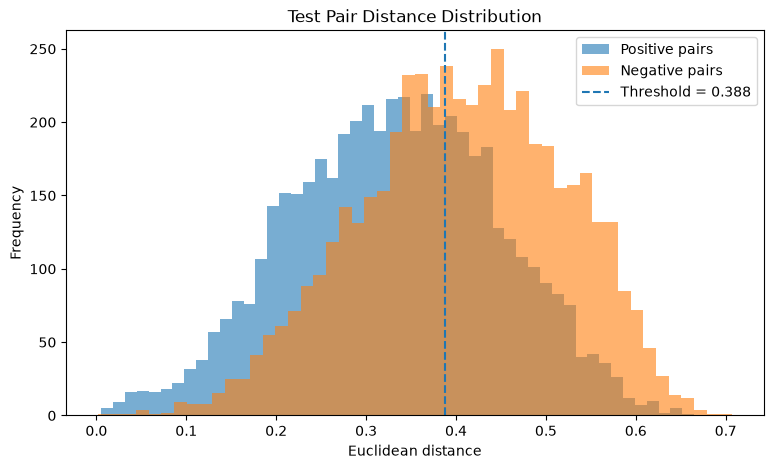

In [34]:
positive_test_distances = (
    test_distances[
        test_targets == 1
    ]
)


negative_test_distances = (
    test_distances[
        test_targets == 0
    ]
)


plt.figure(
    figsize=(9, 5)
)


plt.hist(

    positive_test_distances,

    bins=50,

    alpha=0.6,

    label=
        "Positive pairs"
)


plt.hist(

    negative_test_distances,

    bins=50,

    alpha=0.6,

    label=
        "Negative pairs"
)


plt.axvline(

    best_threshold,

    linestyle="--",

    label=
        f"Threshold = "
        f"{best_threshold:.3f}"
)


plt.xlabel(
    "Euclidean distance"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Test Pair Distance Distribution"
)

plt.legend()

plt.show()

[[2851 2164]
 [1640 3345]]


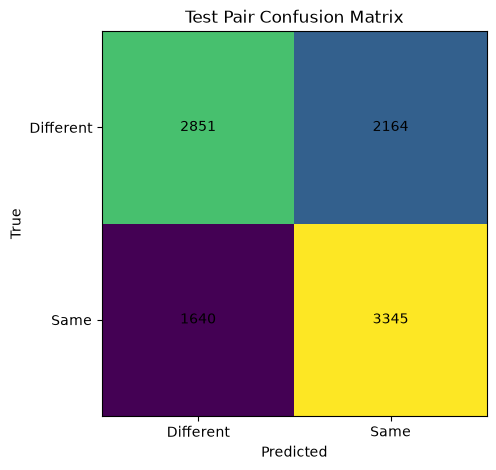

In [35]:
test_predictions = (

    test_distances
    <=
    best_threshold

).astype(int)


cm = confusion_matrix(

    test_targets,

    test_predictions,

    labels=[
        0,
        1
    ]
)


print(
    cm
)


fig, ax = plt.subplots(
    figsize=(5, 5)
)


image = ax.imshow(
    cm
)


ax.set_xticks(
    [0, 1]
)

ax.set_yticks(
    [0, 1]
)


ax.set_xticklabels(
    [
        "Different",
        "Same"
    ]
)


ax.set_yticklabels(
    [
        "Different",
        "Same"
    ]
)


ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "True"
)


ax.set_title(
    "Test Pair Confusion Matrix"
)


for i in range(2):

    for j in range(2):

        ax.text(

            j,
            i,

            str(
                cm[i, j]
            ),

            ha="center",

            va="center"
        )


plt.show()

In [36]:
RESULTS_PATH = (
    ARTIFACTS_DIR
    / "pair_metrics_margin_075.json"
)


results = {

    "best_epoch":
        int(
            checkpoint["epoch"]
        ),

    "best_val_loss":
        float(
            checkpoint["val_loss"]
        ),

    "threshold":
        float(
            best_threshold
        ),

    "embedding_dim":
        EMBEDDING_DIM,

    "margin":
        MARGIN,

    "k":
        DEFAULT_K,

    "validation":
        {
            key:
                float(value)

            for key, value
            in val_metrics.items()
        },

    "test":
        {
            key:
                float(value)

            for key, value
            in test_metrics.items()
        },

    "best_val_roc_auc":
    float(
        checkpoint[
            "val_roc_auc"
        ]
    ),

    "normalization":
        "GroupNorm",

    "learning_rate":
        LEARNING_RATE,

    "batch_size":
        BATCH_SIZE,

    "forward_strategy":
        "concatenated",
}


with open(
    RESULTS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        results,
        f,
        indent=4
    )


print(
    "Risultati salvati:",
    RESULTS_PATH
)

Risultati salvati: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\siamese_margin_075\pair_metrics_margin_075.json


# Conclusioni

È stata implementata una prima CNN Siamese per l'analisi delle FCGR
derivate dalle sequenze eccDNA.

I due input vengono elaborati dallo stesso CNN encoder, che genera
embedding normalizzati di 128 dimensioni.

Il modello viene addestrato mediante Contrastive Loss e distanza euclidea:

- le coppie positive vengono spinte verso distanze ridotte;
- le coppie negative vengono spinte oltre un margine prefissato.

La soglia utilizzata per distinguere pair positivi e negativi viene
determinata esclusivamente sul validation set.

Il test set viene utilizzato solamente dopo la selezione del modello e
della soglia.

Questa configurazione rappresenta la baseline di metric learning del
progetto.

I passi successivi comprenderanno:

- analisi degli embedding;
- classificazione multiclass mediante prototipi di classe;
- confronto con cosine similarity;
- confronto con altre loss metric-learning;
- ablation study sulla dimensione dell'embedding e sul valore di k.